# Logistic Regression
## class_weights

In [12]:
# ---- class_weight comparison: does weighting the minority class reduce false negatives? ----
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, recall_score
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [3]:
# Rebuild X, y (Amyloid + Total tau, MCI only) — same as cell 45
df = pd.read_csv("data/plasma_lipidomics.csv")

In [7]:
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy()
amyloid_median = mci['CSF Amyloid (pg/mL)'].median()
mci['CSF Amyloid (pg/mL)'] = mci['CSF Amyloid (pg/mL)'].fillna(amyloid_median)
tau_median = mci['CSF Total tau (pg/mL)'].median()
mci['CSF Total tau (pg/mL)'] = mci['CSF Total tau (pg/mL)'].fillna(tau_median)

mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)']]

print("Class balance (0=No progression, 1=Progressed):")
print(y.value_counts(), "\n")

Class balance (0=No progression, 1=Progressed):
target
1    47
0    42
Name: count, dtype: int64 



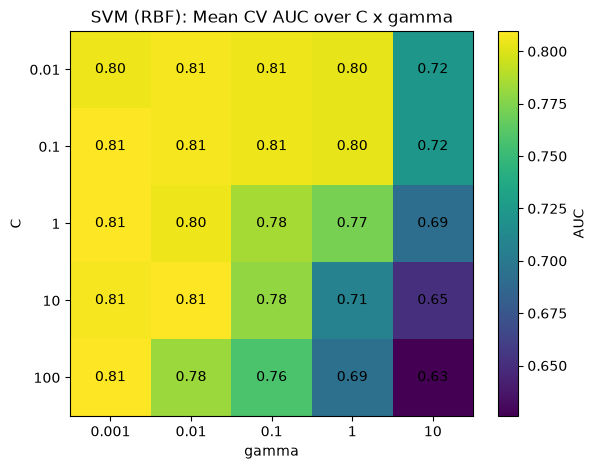

Best: 0.1 0.001 0.8097222222222223


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

from sklearn.svm import SVC

C_vals = [0.01, 0.1, 1, 10, 100]
gamma_vals = [0.001, 0.01, 0.1, 1, 10]
heat = np.zeros((len(C_vals), len(gamma_vals)))

for i, C in enumerate(C_vals):
    for j, g in enumerate(gamma_vals):
        pipe = Pipeline([('sc', StandardScaler()),
                          ('clf', SVC(C=C, gamma=g, probability=True, random_state=42))])
        score = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
        heat[i, j] = score.mean()

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(heat, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(gamma_vals))); ax.set_xticklabels(gamma_vals)
ax.set_yticks(range(len(C_vals))); ax.set_yticklabels(C_vals)
ax.set_xlabel('gamma'); ax.set_ylabel('C')
ax.set_title('SVM (RBF): Mean CV AUC over C x gamma')
for i in range(len(C_vals)):
    for j in range(len(gamma_vals)):
        ax.text(j, i, f"{heat[i,j]:.2f}", ha='center', va='center')
plt.colorbar(im, ax=ax, label='AUC')
plt.savefig(f"images/uac_gamma", dpi=300, bbox_inches="tight")
plt.show()

best_i, best_j = np.unravel_index(np.argmax(heat), heat.shape)
print("Best:", C_vals[best_i], gamma_vals[best_j], heat.max())